In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np

In [2]:
log_path = "./tests/run_parallel/logs400/"
all_success = []

In [3]:
# Lê os dados e separa em quartis, somando o número de sucessos por operador
for method in range(3):
    csv_files = glob.glob(os.path.join(log_path, f"VNS{method}_*.csv"))
    
    for f in csv_files:
        df = pd.read_csv(f)
        df["Execution"] = os.path.splitext(os.path.basename(f))[0]
        df["Method"] = f"VNS{method}"

        # Ordenar por progresso
        df = df.sort_values(by="Evaluations").reset_index(drop=True)

        # Quartis
        quartil_labels = ['Q1', 'Q2', 'Q3', 'Q4']
        df['Quartil'] = np.concatenate([
            np.repeat(label, len(split)) for label, split in zip(quartil_labels, np.array_split(df.index, 4))
        ])

        # Conta sucessos por operador em cada quartil
        success_counts = (
            df[df["Success"] == 1]
            .groupby(["Operator", "Quartil"])
            .size()
            .reset_index(name="Success Count")
        )
        success_counts["Method"] = f"VNS{method}"
        all_success.append(success_counts)

# Junta tudo
df_success = pd.concat(all_success, ignore_index=True)

# Agora soma os sucessos por operador + quartil + método (30 execuções)
df_grouped = df_success.groupby(["Method", "Operator", "Quartil"])["Success Count"].sum().reset_index()

# Gera um gráfico por VNS
methods = df_grouped["Method"].unique()
quartil_order = ['Q1', 'Q2', 'Q3', 'Q4']

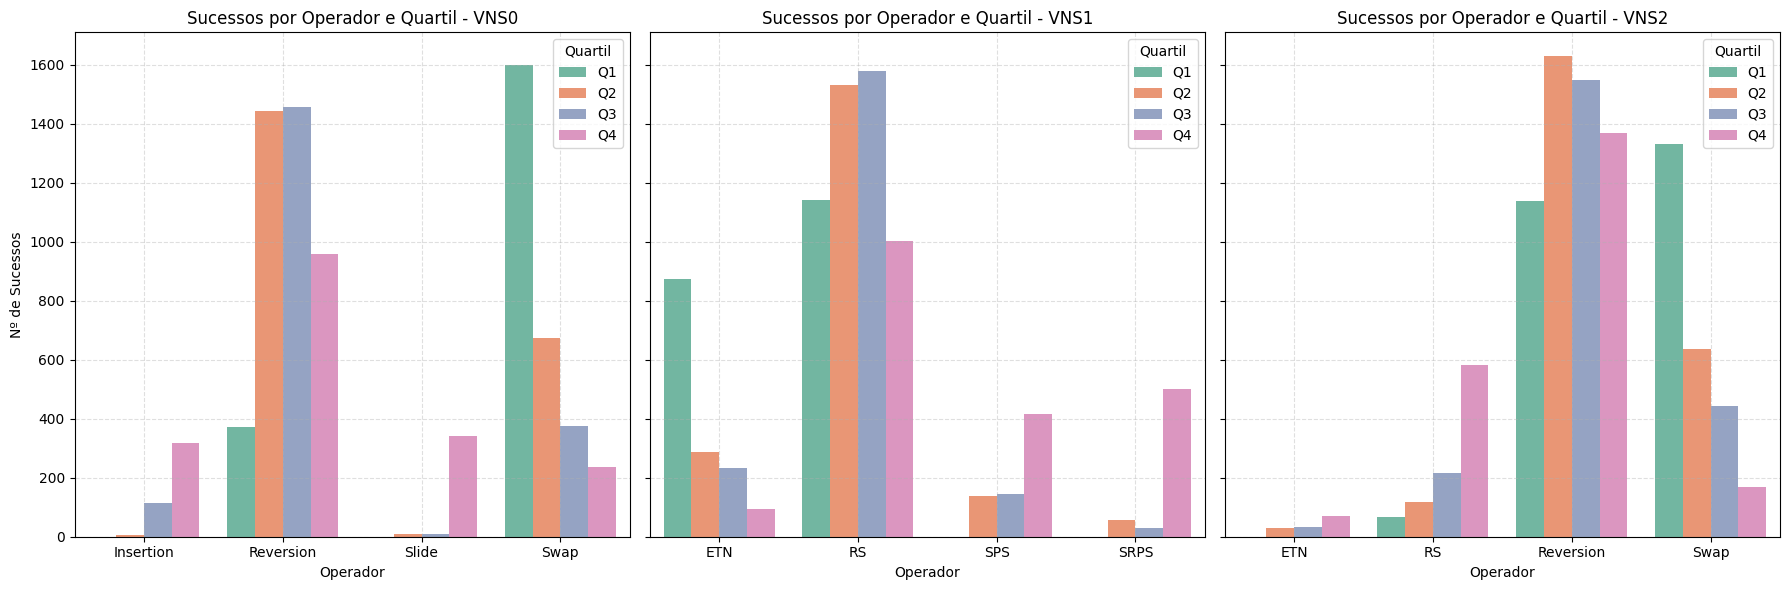

In [4]:
fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 6), sharey=True)

if len(methods) == 1:
    axes = [axes]

for method, ax in zip(methods, axes):
    subset = df_grouped[df_grouped["Method"] == method]
    
    sns.barplot(
        data=subset,
        x="Operator",
        y="Success Count",
        hue="Quartil",
        hue_order=quartil_order,
        palette="Set2",
        ax=ax
    )
    
    ax.set_title(f'Sucessos por Operador e Quartil - {method}')
    ax.set_xlabel("Operador")
    if method == methods[0]:
        ax.set_ylabel("Nº de Sucessos")
    else:
        ax.set_ylabel("")
    ax.legend(title="Quartil")
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

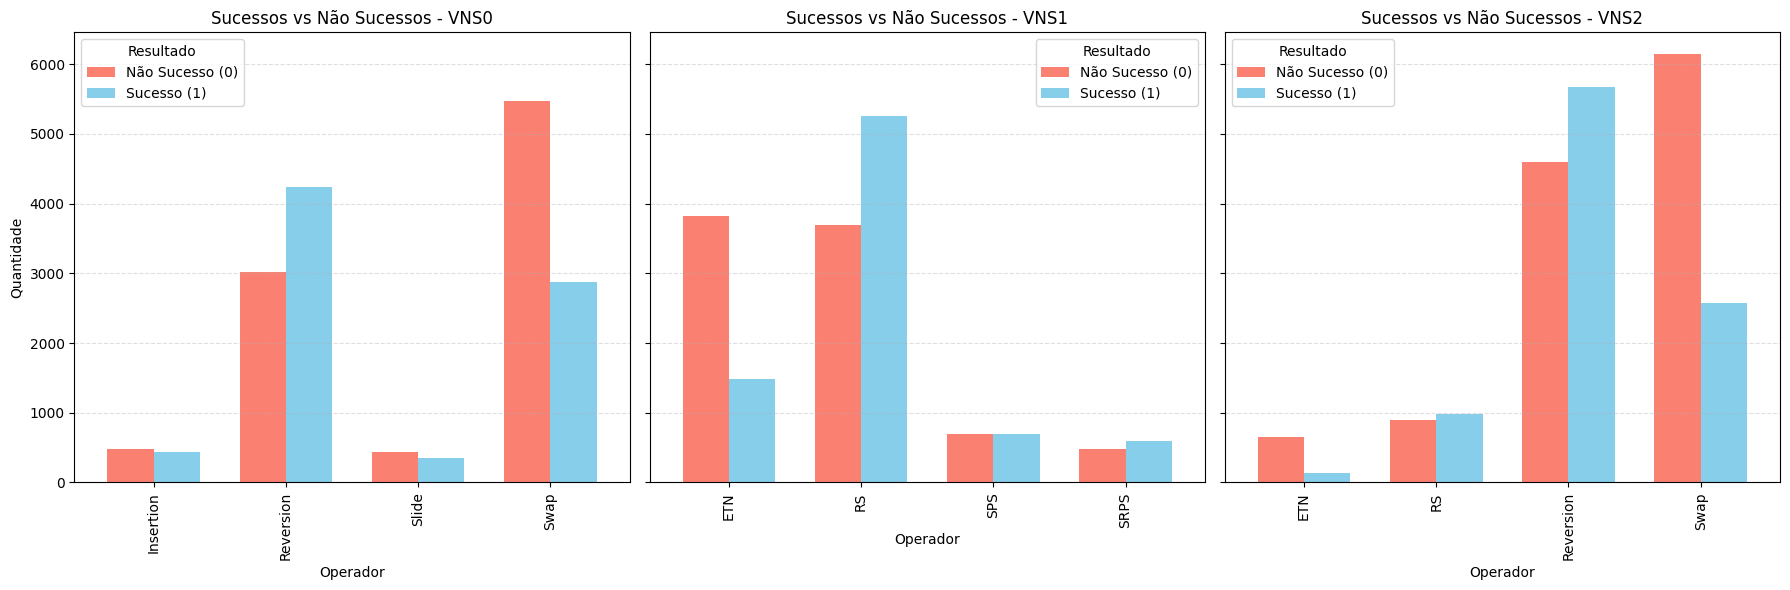

In [6]:
# Primeiro, ler todos os arquivos e juntar sucessos e fracassos
all_success_failure = []

for method in range(3):
    csv_files = glob.glob(os.path.join(log_path, f"VNS{method}_*.csv"))
    
    for f in csv_files:
        df = pd.read_csv(f)
        df["Execution"] = os.path.splitext(os.path.basename(f))[0]
        df["Method"] = f"VNS{method}"
        
        all_success_failure.append(df[["Operator", "Success", "Method", "Execution"]])

# Juntar tudo
df_sf = pd.concat(all_success_failure, ignore_index=True)

# Agora separar por método
methods = df_sf["Method"].unique()

# Plotar lado a lado
fig, axes = plt.subplots(1, len(methods), figsize=(6 * len(methods), 6), sharey=True)

if len(methods) == 1:
    axes = [axes]

for method, ax in zip(methods, axes):
    subset = df_sf[df_sf["Method"] == method]
    
    # Contar sucessos (1) e fracassos (0) por operador
    counts = subset.groupby(["Operator", "Success"]).size().unstack(fill_value=0)
    
    # Fazer o gráfico de barras agrupadas
    counts.plot(kind="bar", ax=ax, color=["salmon", "skyblue"], width=0.7)
    
    ax.set_title(f'Sucessos vs Não Sucessos - {method}')
    ax.set_xlabel("Operador")
    if method == methods[0]:
        ax.set_ylabel("Quantidade")
    else:
        ax.set_ylabel("")
    
    ax.legend(["Não Sucesso (0)", "Sucesso (1)"], title="Resultado")
    ax.grid(axis="y", linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()